In [238]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn import tree
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, mean_squared_error
from sklearn.feature_extraction import DictVectorizer

from sklearn.ensemble import RandomForestRegressor

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text


In [239]:
df=pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv")
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [240]:
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [241]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [242]:
df.shape

(9704, 11)

In [243]:
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9222.000000,8996.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000
mean,199.708368,3.962481,149.657292,3001.280993,15.021928,2011.484027,-0.006412,14.985243
std,49.455319,1.999323,29.879555,497.894860,2.510339,6.659808,1.048162,2.556468
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971
25%,170.000000,3.000000,130.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,149.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,170.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


In [244]:
df.num_doors.value_counts()

num_doors
 0.0    3551
 1.0    2192
-1.0    2183
-2.0     594
 2.0     563
 3.0      58
-3.0      56
-4.0       4
 4.0       1
Name: count, dtype: int64

In [245]:
df["num_doors"] = df["num_doors"].abs()


In [246]:
df.num_doors.value_counts()

num_doors
1.0    4375
0.0    3551
2.0    1157
3.0     114
4.0       5
Name: count, dtype: int64

In [247]:
df['num_doors'] = df['num_doors'].mask(df['num_doors'] <= 0, np.nan)
df['num_doors'] = df['num_doors'].fillna(df['num_doors'].mode()[0])

In [248]:
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,1.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,1.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,1.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,1.0,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,1.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [249]:
df.origin.value_counts()

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64

In [250]:
# origin_values = {
#     'Europe':1,
#     'Asia':2,
#     'USA':3
# }
# df.origin = df.origin.map(origin_values)

In [251]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [252]:
df.fuel_type.value_counts()

fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64

In [253]:
# fuel_values = {
#     1: 'Gasoline',
#     2: 'Diesel',
    
# }
# df.fuel_type = df.fuel_type.map(fuel_values)

In [254]:
df.drivetrain.value_counts()

drivetrain
All-wheel drive      4876
Front-wheel drive    4828
Name: count, dtype: int64

In [255]:
# drivetrain_values = {
#     1: 'All_wheel_drive',
#     2: 'Front_wheel_drive',
    
# }
# df.drivetrain = df.drivetrain.map(drivetrain_values)

In [256]:
# fill missing values with zero

numeric_columns = list(df.dtypes[df.dtypes != 'object'].index)

for col in numeric_columns:
    df[col] = df[col].fillna(0)

In [257]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,1.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,1.0,13.688217
2,170,0.0,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,1.0,14.246341
3,220,4.0,0.0,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [258]:
df.isna().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [259]:
len(df)

9704

In [260]:
df_train, df_temp = train_test_split(df, test_size=0.4, random_state=1)
df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=1)

len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [261]:
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
4150,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,1.0,17.163765
5660,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,1.0,12.363335
7319,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,2.0,18.658431
1562,110,3.0,136.0,3307.407159,15.9,2010,USA,Gasoline,All-wheel drive,2.0,12.385063
7499,220,2.0,190.0,3315.299773,18.3,2017,USA,Diesel,Front-wheel drive,1.0,13.468627
...,...,...,...,...,...,...,...,...,...,...,...
2895,130,3.0,135.0,3848.980605,16.7,2002,Asia,Diesel,Front-wheel drive,1.0,10.012980
7813,170,2.0,129.0,3749.153246,15.5,2013,Asia,Gasoline,Front-wheel drive,1.0,11.433173
905,230,3.0,178.0,2596.657191,16.5,2000,Europe,Diesel,Front-wheel drive,1.0,16.724633
5192,270,4.0,113.0,1860.388023,12.2,2017,Asia,Gasoline,Front-wheel drive,1.0,20.364344


In [262]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [263]:
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,1.0,17.163765
1,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,1.0,12.363335
2,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,2.0,18.658431
3,110,3.0,136.0,3307.407159,15.9,2010,USA,Gasoline,All-wheel drive,2.0,12.385063
4,220,2.0,190.0,3315.299773,18.3,2017,USA,Diesel,Front-wheel drive,1.0,13.468627
...,...,...,...,...,...,...,...,...,...,...,...
5817,130,3.0,135.0,3848.980605,16.7,2002,Asia,Diesel,Front-wheel drive,1.0,10.012980
5818,170,2.0,129.0,3749.153246,15.5,2013,Asia,Gasoline,Front-wheel drive,1.0,11.433173
5819,230,3.0,178.0,2596.657191,16.5,2000,Europe,Diesel,Front-wheel drive,1.0,16.724633
5820,270,4.0,113.0,1860.388023,12.2,2017,Asia,Gasoline,Front-wheel drive,1.0,20.364344


In [264]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [265]:
len(y_train), len(y_val), len(y_test)

(5822, 1941, 1941)

In [266]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [267]:
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,1.0
1,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,1.0
2,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,2.0
3,110,3.0,136.0,3307.407159,15.9,2010,USA,Gasoline,All-wheel drive,2.0
4,220,2.0,190.0,3315.299773,18.3,2017,USA,Diesel,Front-wheel drive,1.0
...,...,...,...,...,...,...,...,...,...,...
5817,130,3.0,135.0,3848.980605,16.7,2002,Asia,Diesel,Front-wheel drive,1.0
5818,170,2.0,129.0,3749.153246,15.5,2013,Asia,Gasoline,Front-wheel drive,1.0
5819,230,3.0,178.0,2596.657191,16.5,2000,Europe,Diesel,Front-wheel drive,1.0
5820,270,4.0,113.0,1860.388023,12.2,2017,Asia,Gasoline,Front-wheel drive,1.0


In [193]:
train_dicts = df_train.fillna(0).to_dict(orient='records')

In [194]:
train_dicts[0:5]

[{'engine_displacement': 150,
  'num_cylinders': 5.0,
  'horsepower': 0.0,
  'vehicle_weight': 2510.4108964056463,
  'acceleration': 10.0,
  'model_year': 2010,
  'origin': 'Europe',
  'fuel_type': 'Gasoline',
  'drivetrain': 'Front-wheel drive',
  'num_doors': 1.0},
 {'engine_displacement': 200,
  'num_cylinders': 3.0,
  'horsepower': 181.0,
  'vehicle_weight': 3597.483662621028,
  'acceleration': 12.7,
  'model_year': 2006,
  'origin': 'Europe',
  'fuel_type': 'Diesel',
  'drivetrain': 'Front-wheel drive',
  'num_doors': 1.0},
 {'engine_displacement': 220,
  'num_cylinders': 6.0,
  'horsepower': 118.0,
  'vehicle_weight': 2217.3496247828057,
  'acceleration': 0.0,
  'model_year': 2004,
  'origin': 'USA',
  'fuel_type': 'Diesel',
  'drivetrain': 'All-wheel drive',
  'num_doors': 2.0},
 {'engine_displacement': 110,
  'num_cylinders': 3.0,
  'horsepower': 136.0,
  'vehicle_weight': 3307.407159469786,
  'acceleration': 15.9,
  'model_year': 2010,
  'origin': 'USA',
  'fuel_type': 'Gasoli

In [195]:
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)

In [196]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 58220 stored elements and shape (5822, 14)>

In [197]:
dv.feature_names_

['acceleration',
 'drivetrain=All-wheel drive',
 'drivetrain=Front-wheel drive',
 'engine_displacement',
 'fuel_type=Diesel',
 'fuel_type=Gasoline',
 'horsepower',
 'model_year',
 'num_cylinders',
 'num_doors',
 'origin=Asia',
 'origin=Europe',
 'origin=USA',
 'vehicle_weight']

In [198]:
# test
reg = DecisionTreeRegressor(max_depth=1, random_state=0)
reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [200]:
test_dicts = df_test.fillna(0).to_dict(orient='records')
X_test = dv.fit_transform(test_dicts)

In [201]:
y_pred = reg.predict(X_test)

[Text(0.5, 0.75, 'vehicle_weight <= 3028.823\nsquared_error = 6.533\nsamples = 5822\nvalue = 14.966'),
 Text(0.25, 0.25, 'squared_error = 2.636\nsamples = 3059\nvalue = 16.857'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 2.503\nsamples = 2763\nvalue = 12.872'),
 Text(0.625, 0.5, '  False')]

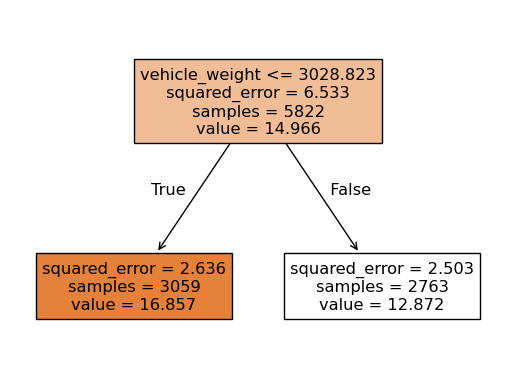

In [203]:
tree.plot_tree(reg, feature_names=dv.feature_names_, filled=True)

In [204]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.fit_transform(val_dicts)

In [206]:
reg = RandomForestRegressor(
    n_estimators=10,
    random_state=1,
    n_jobs=-1
)
reg.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [207]:
y_pred = reg.predict(X_val)

In [210]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("RMSE on validation set:", rmse)

RMSE on validation set: 0.46069610665397764


In [211]:
rmse_list = []
n_estimators_range = range(10, 201, 10)
for n_estimators in n_estimators_range:
    reg = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=1,
        n_jobs=-1
    )
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_list.append(round(rmse, 3))

# Find first n_estimators after which RMSE stops improving (rounded to 3 decimals)
best_rmse = rmse_list[0]
answer_n = n_estimators_range[0]
for idx, rmse in enumerate(rmse_list[1:], 1):
    if rmse < best_rmse:
        best_rmse = rmse
        answer_n = n_estimators_range[idx]
    elif round(rmse, 3) >= round(best_rmse, 3):
        answer_n = n_estimators_range[idx]
        break
else:
    answer_n = n_estimators_range[-1]

# Print results
print("RMSE for each n_estimators test:", rmse_list)
print("n_estimators after which RMSE stops improving:", answer_n)

RMSE for each n_estimators test: [np.float64(0.461), np.float64(0.447), np.float64(0.441), np.float64(0.439), np.float64(0.437), np.float64(0.436), np.float64(0.436), np.float64(0.436), np.float64(0.436), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.435), np.float64(0.434)]
n_estimators after which RMSE stops improving: 70


In [219]:
max_depths = [10, 15, 20, 25]
n_estimators_list = range(10, 201, 10)
mean_rmses = []

for max_depth in max_depths:
    rmses = []
    for n_estimators in n_estimators_list:
        reg = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=1,
            n_jobs=-1
        )
        reg.fit(X_train, y_train)
        y_pred = reg.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmses.append(rmse)
    mean_rmse = np.mean(rmses)
    mean_rmses.append(mean_rmse)
    print(f"max_depth={max_depth}, mean RMSE={mean_rmse:.3f}")

best_idx = np.argmin(mean_rmses)
best_max_depth = max_depths[best_idx]
print(f"Best max_depth: {best_max_depth} (Mean RMSE: {mean_rmses[best_idx]:.3f})")

max_depth=10, mean RMSE=0.436
max_depth=15, mean RMSE=0.438
max_depth=20, mean RMSE=0.438
max_depth=25, mean RMSE=0.438
Best max_depth: 10 (Mean RMSE: 0.436)


In [216]:
df_train2 = df_train[['vehicle_weight', 'horsepower', 'acceleration', 'engine_displacement']]
df_train2

,vehicle_weight,horsepower,acceleration,engine_displacement
0,2510.410896,0.0,10.0,150
1,3597.483663,181.0,12.7,200
2,2217.349625,118.0,0.0,220
3,3307.407159,136.0,15.9,110
4,3315.299773,190.0,18.3,220
...,...,...,...,...
5817,3848.980605,135.0,16.7,130
5818,3749.153246,129.0,15.5,170
5819,2596.657191,178.0,16.5,230
5820,1860.388023,113.0,12.2,270


In [ ]:
X = df_train2

In [218]:
# Train model with specified parameters
reg = RandomForestRegressor(
    n_estimators=10,
    max_depth=20,
    random_state=1,
    n_jobs=-1
)
reg.fit(X, y_train)

# Get feature importances
importances = reg.feature_importances_
feature_names = X.columns

# Print feature importances
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.3f}")

# Find most important feature
most_important = feature_names[importances.argmax()]
print("Most important feature:", most_important)

vehicle_weight: 0.963
horsepower: 0.018
acceleration: 0.014
engine_displacement: 0.005
Most important feature: vehicle_weight


In [268]:
df_train.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
dtype: object

In [270]:
# Ensure string/object categorical columns are converted to pandas 'category' dtype
cat_cols = ['origin', 'fuel_type', 'drivetrain']
for col in cat_cols:
	if col in df_train.columns:
		df_train[col] = df_train[col].astype('category')
	if col in df_val.columns:
		df_val[col] = df_val[col].astype('category')
	if col in df_test.columns:
		df_test[col] = df_test[col].astype('category')

dtrain = xgb.DMatrix(df_train, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(df_val, label=y_val, enable_categorical=True)
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [271]:
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,150,5.0,0.0,2510.410896,10.0,2010,Europe,Gasoline,Front-wheel drive,1.0
1,200,3.0,181.0,3597.483663,12.7,2006,Europe,Diesel,Front-wheel drive,1.0
2,220,6.0,118.0,2217.349625,0.0,2004,USA,Diesel,All-wheel drive,2.0
3,110,3.0,136.0,3307.407159,15.9,2010,USA,Gasoline,All-wheel drive,2.0
4,220,2.0,190.0,3315.299773,18.3,2017,USA,Diesel,Front-wheel drive,1.0
...,...,...,...,...,...,...,...,...,...,...
5817,130,3.0,135.0,3848.980605,16.7,2002,Asia,Diesel,Front-wheel drive,1.0
5818,170,2.0,129.0,3749.153246,15.5,2013,Asia,Gasoline,Front-wheel drive,1.0
5819,230,3.0,178.0,2596.657191,16.5,2000,Europe,Diesel,Front-wheel drive,1.0
5820,270,4.0,113.0,1860.388023,12.2,2017,Asia,Gasoline,Front-wheel drive,1.0


In [272]:
params_03 = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'nthread': 8,
    'seed': 1,
    'verbosity': 1,
}
model_03 = xgb.train(params_03, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=False)
preds_03 = model_03.predict(dval)
rmse_03 = np.sqrt(mean_squared_error(y_val, preds_03))

params_01 = params_03.copy()
params_01['eta'] = 0.1
model_01 = xgb.train(params_01, dtrain, num_boost_round=100, evals=watchlist, verbose_eval=False)
preds_01 = model_01.predict(dval)
rmse_01 = np.sqrt(mean_squared_error(y_val, preds_01))

print(f"RMSE eta 0.3: {rmse_03:.3f}")
print(f"RMSE eta 0.1: {rmse_01:.3f}")


RMSE eta 0.3: 0.442
RMSE eta 0.1: 0.416
